In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [2]:
df = pd.read_csv("solar_power_output.csv")
df.head()

,temperature,humidity,solar_irradiance,wind_speed,solar_power_output
0,19.363503,75.852937,266.619636,5.190818,128.101772
1,33.767858,62.887709,587.710853,4.791819,290.911789
2,28.299849,44.762209,885.651252,0.256421,442.336390
3,24.966462,85.103602,759.002398,3.412478,380.261988
4,13.900466,74.778494,825.905033,3.801956,415.931953


In [3]:
X = df[['temperature' ,'humidity' ,'solar_irradiance' , 'wind_speed' ]]
y = df['solar_power_output' ]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [6]:
y_pred = model.predict(X_test)

In [7]:
y_pred

array([145.57713107,  58.80813607, 162.02529472, 389.82145928,
       499.91950594, 201.0282157 , 280.32773311, 343.94995963,
       207.65845171, 274.08855807, 270.4758993 ,  71.45181397,
       429.2717113 , 474.93452177, 131.00879232, 488.72382531,
       351.97648481,  66.01156114, 286.53039285, 315.26996554,
       156.25649583, 217.68415494, 328.50926609, 456.09724416,
       224.5996492 , 343.33441394, 258.65661936, 253.27035924,
       487.33886964, 488.13938702, 352.87341423, 139.35221981,
       486.2457442 , 166.59050109, 443.99714231, 498.93693591,
       440.23818941, 184.21480104, 497.81182991, 239.22808162,
       345.26650268, 281.34107991, 215.84679473, 472.53738059,
       105.19383876, 353.92961078, 132.62179771, 496.30985098,
       472.03357268, 464.32390435,  68.39576647, 337.05784428,
       271.45779664, 142.00782194, 330.57420011, 209.16463829,
       431.33413852, 460.5254782 , 271.68335513, 148.17216826,
       322.32496321, 189.54364635, 148.80585848,  54.32

In [8]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 29.462345968246385
R-squared: 0.9983255901416407


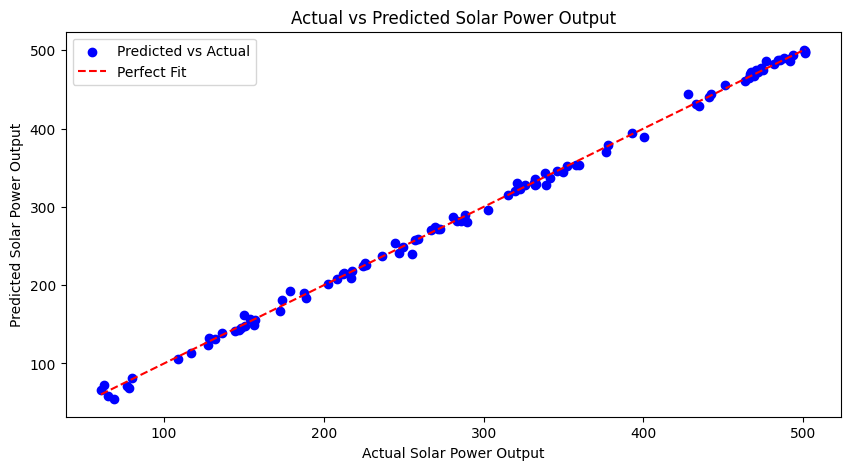

In [9]:
import matplotlib.pyplot as plt

# Scatter plot to compare actual vs predicted values
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
# Diagonal line for perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Fit')
plt.xlabel("Actual Solar Power Output")
plt.ylabel("Predicted Solar Power Output")
plt.title("Actual vs Predicted Solar Power Output")
plt.legend()
plt.show()

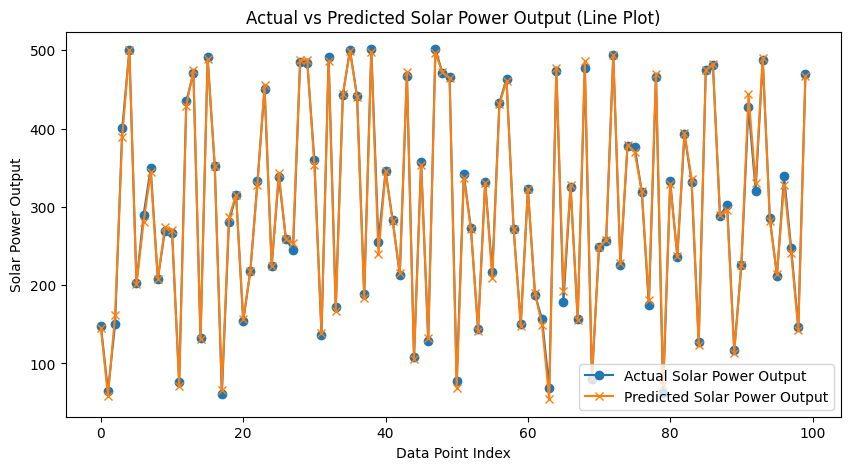

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(y_test)), y_test, label="Actual Solar Power Output", marker='o')
plt.plot(range(len(y_test)), y_pred, label="Predicted Solar Power Output", marker='x')
plt.xlabel("Data Point Index")
plt.ylabel("Solar Power Output")
plt.title("Actual vs Predicted Solar Power Output (Line Plot)")
plt.legend()
plt.show()

In [11]:
joblib.dump(model, 'solar_power_prediction_model.pkl')

['solar_power_prediction_model.pkl']

In [12]:
model = joblib. load("solar_power_prediction_model.pkl")

# New input data for prediction
# Example input (temperature, humidity, solar_irradiance,wind_speed)
new_data = np.array([[19.36, 75.85,266.61,5.19]])

# Predict solar power output
predicted_output = model.predict(new_data)
print(f"Predicted Solar Power Output: {predicted_output[0]} watts")

Predicted Solar Power Output: 132.6167057318903 watts


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [14]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 27.4 MB/s eta 0:00:00


In [16]:
!pip install -q streamlit pyngrok pandas scikit-learn joblib

In [18]:
!pip install -q streamlit pyngrok

In [19]:
%%writefile /content/app.py

import streamlit as st
import pandas as pd
import joblib
from pathlib import Path

# -----------------------------
# Page Configuration
# -----------------------------
st.set_page_config(
    page_title="Solar Power Prediction",
    page_icon="☀️",
    layout="wide"
)

# -----------------------------
# Custom CSS
# -----------------------------
st.markdown("""
<style>
.hero {
    padding: 30px;
    border-radius: 18px;
    background: linear-gradient(135deg, #fff7d6, #eaf7ff);
    margin-bottom: 25px;
}

.hero h1 {
    font-size: 40px;
    margin-bottom: 10px;
}

.hero p {
    font-size: 18px;
    color: #555;
}

.result-card {
    padding: 25px;
    border-radius: 16px;
    background: #f5f7fa;
    border: 1px solid #ddd;
    text-align: center;
}

.result-value {
    font-size: 38px;
    font-weight: bold;
}
</style>
""", unsafe_allow_html=True)

# -----------------------------
# Load Model
# -----------------------------
MODEL_PATH = Path("/content/solar_power_prediction_model.pkl")

@st.cache_resource
def load_model():
    return joblib.load(MODEL_PATH)

try:
    model = load_model()
except Exception as e:
    st.error("Model could not be loaded.")
    st.exception(e)
    st.stop()

# -----------------------------
# Header
# -----------------------------
st.markdown("""
<div class="hero">
    <h1>☀️ Solar Power Output Prediction</h1>
    <p>
        Predict solar power generation using environmental
        and weather parameters with Machine Learning.
    </p>
</div>
""", unsafe_allow_html=True)

# -----------------------------
# Sidebar
# -----------------------------
with st.sidebar:
    st.header("⚙️ Prediction Settings")
    st.write("Enter the environmental parameters.")
    st.info("Use realistic weather values for better predictions.")

# -----------------------------
# Input Parameters
# -----------------------------
st.subheader("📊 Environmental Parameters")

col1, col2 = st.columns(2)

with col1:
    temperature = st.number_input(
        "🌡️ Temperature",
        min_value=-50.0,
        max_value=80.0,
        value=25.0,
        step=0.1
    )

    solar_irradiance = st.number_input(
        "☀️ Solar Irradiance (W/m²)",
        min_value=0.0,
        max_value=2000.0,
        value=500.0,
        step=1.0
    )

with col2:
    humidity = st.number_input(
        "💧 Humidity (%)",
        min_value=0.0,
        max_value=100.0,
        value=50.0,
        step=0.1
    )

    wind_speed = st.number_input(
        "🌬️ Wind Speed (m/s)",
        min_value=0.0,
        max_value=100.0,
        value=5.0,
        step=0.1
    )

# -----------------------------
# Prediction Button
# -----------------------------
if st.button(
    "🔮 Predict Solar Power",
    type="primary",
    use_container_width=True
):

    input_data = pd.DataFrame({
        "temperature": [temperature],
        "humidity": [humidity],
        "solar_irradiance": [solar_irradiance],
        "wind_speed": [wind_speed]
    })

    try:
        prediction = model.predict(input_data)[0]

        st.success("Prediction completed successfully!")

        st.markdown(f"""
        <div class="result-card">
            <h3>⚡ Predicted Solar Power Output</h3>
            <div class="result-value">
                {prediction:,.2f}
            </div>
        </div>
        """, unsafe_allow_html=True)

        st.subheader("📌 Input Summary")

        m1, m2, m3, m4 = st.columns(4)

        m1.metric("Temperature", f"{temperature:.1f} °C")
        m2.metric("Humidity", f"{humidity:.1f} %")
        m3.metric("Irradiance", f"{solar_irradiance:.1f} W/m²")
        m4.metric("Wind Speed", f"{wind_speed:.1f} m/s")

        with st.expander("🔍 View Model Input"):
            st.dataframe(input_data, use_container_width=True)

    except Exception as e:
        st.error("Prediction failed.")
        st.exception(e)

# -----------------------------
# Footer
# -----------------------------
st.divider()

st.markdown("""
<div style="text-align:center;">
    <small>
        ☀️ Solar Power Prediction System |
        Python • Pandas • Machine Learning • Streamlit
    </small>
</div>
""", unsafe_allow_html=True)

Writing /content/app.py


In [20]:
%%writefile /content/requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib

Writing /content/requirements.txt
